In [12]:
import nltk
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import torch
from nltk.corpus import cmudict
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


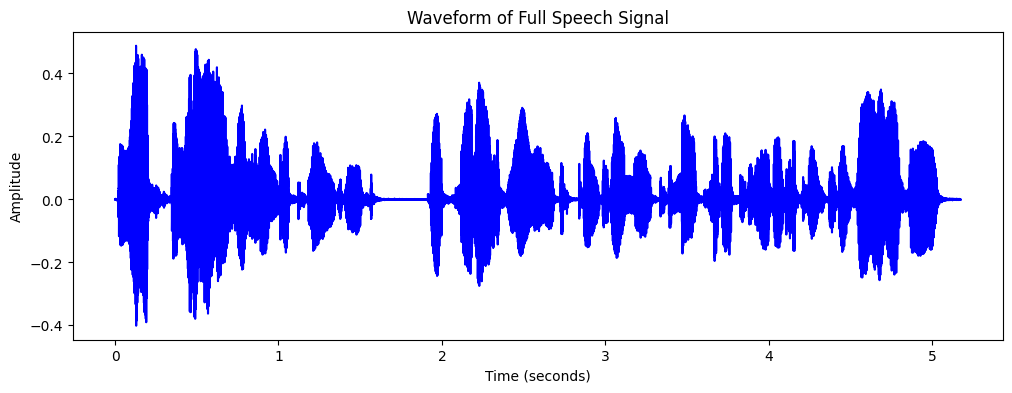

Recognized Text: THE F B I HAS INDICATED THAT IT IS WILLING TO CONTINUE TO MAKE SUCH ASSISTANCE AVAILABLE
Recognized Phonemes (ARPAbet): DH AH0 EH1 F B IY1 AY1 HH AE1 Z IH1 N D AH0 K EY2 T AH0 D DH AE1 T IH1 T IH1 Z W IH1 L IH0 NG T UW1 K AH0 N T IH1 N Y UW0 T UW1 M EY1 K S AH1 CH AH0 S IH1 S T AH0 N S AH0 V EY1 L AH0 B AH0 L


In [15]:
# Download CMU Pronouncing Dictionary
nltk.download("cmudict")
cmu_dict = cmudict.dict()

# Load pre-trained model for speech-to-text
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")

# Load audio file (Ensure it's uploaded in Colab)
audio_path = "/content/LJ050-0241.wav"
y, sr = librosa.load(audio_path, sr=16000)

# **Plot Full Speech Waveform**
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, len(y)/sr, len(y)), y, color="blue")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Waveform of Full Speech Signal")
plt.show()

# Process the audio
input_values = processor(y, return_tensors="pt", sampling_rate=16000).input_values

# Perform inference
with torch.no_grad():
    logits = model(input_values).logits

# Decode the predicted tokens into text
predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.decode(predicted_ids[0])

print("Recognized Text:", transcription)

# Function to convert text to ARPAbet phonemes using CMUdict
def text_to_phonemes_cmu(text):
    words = text.lower().split()
    phonemes = []
    for word in words:
        if word in cmu_dict:
            phonemes.append(" ".join(cmu_dict[word][0]))
        else:
            phonemes.append(word)
    return " ".join(phonemes)

# Convert recognized text to ARPAbet phonemes
phoneme_transcription = text_to_phonemes_cmu(transcription)
print("Recognized Phonemes (ARPAbet):", phoneme_transcription)

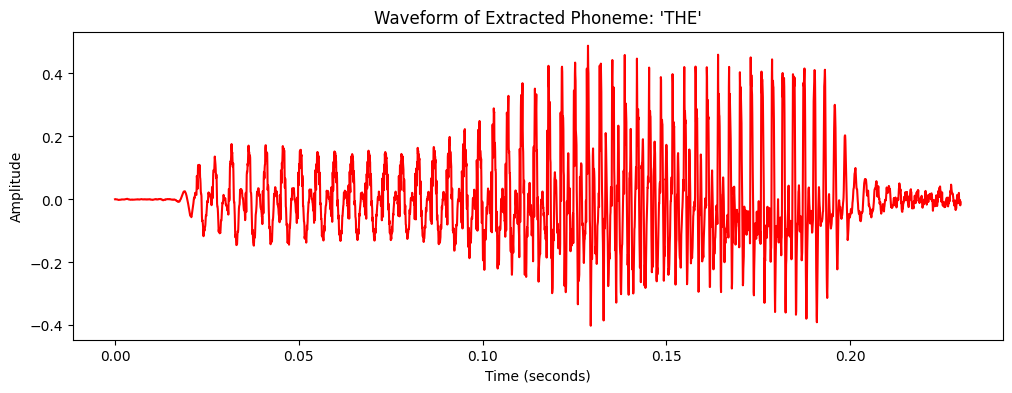

In [16]:
# Extracting and plotting THE phoneme
word_to_extract = "the"
if word_to_extract in transcription.lower().split():
    # Define phoneme segment time manually (you can refine this using forced alignment)
    start_time = 0.0
    end_time = 0.23

    # Convert time to sample indices
    start_sample = int(start_time * sr)
    end_sample = int(end_time * sr)

    # Extract phoneme segment
    phoneme_segment = y[start_sample:end_sample]

    # Time axis for waveform
    time_axis = np.linspace(start_time, end_time, len(phoneme_segment))

    # Plot extracted phoneme waveform
    plt.figure(figsize=(12, 4))
    plt.plot(time_axis, phoneme_segment, color="red")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title(f"Waveform of Extracted Phoneme: '{word_to_extract.upper()}'")
    plt.show()
else:
    print(f"'{word_to_extract}' not found in recognized text.")